# [LAB-06] 데이터 시각화ㅣ14-1-Lm Plot

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import my_plot
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('penguins')
origin


📚 남극 팔머 군도의 펭귄 3종에 대해 신체 치수와 서식지 정보(출처: https://www.kaggle.com/datasets/larsen0966/penguins)

    field              description
--  -----------------  -------------
 0  species            팽귄 종
 1  island             서식지
 2  bill_length_mm     부리 길이
 3  bill_depth_mm      부리 두께
 4  flipper_length_mm  날개 길이
 5  body_mass_g        몸무게
 6  sex                성별



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100,18.700,181,3750,MALE
1,Adelie,Torgersen,39.500,17.400,186,3800,FEMALE
2,Adelie,Torgersen,40.300,18.000,195,3250,FEMALE
3,Adelie,Torgersen,36.700,19.300,193,3450,FEMALE
4,Adelie,Torgersen,39.300,20.600,190,3650,MALE
...,...,...,...,...,...,...,...
329,Gentoo,Biscoe,47.200,13.700,214,4925,FEMALE
330,Gentoo,Biscoe,46.800,14.300,215,4850,FEMALE
331,Gentoo,Biscoe,50.400,15.700,222,5750,MALE
332,Gentoo,Biscoe,45.200,14.800,212,5200,FEMALE


## #02. LmPlot

### 1. LmPlot 기본 시각화 - 부리 길이과 부리 두께의 관계

- pyplot 객체를 직접 초기화 할 수 없다 --> my_plot.init()의 영향을 받지 않는다


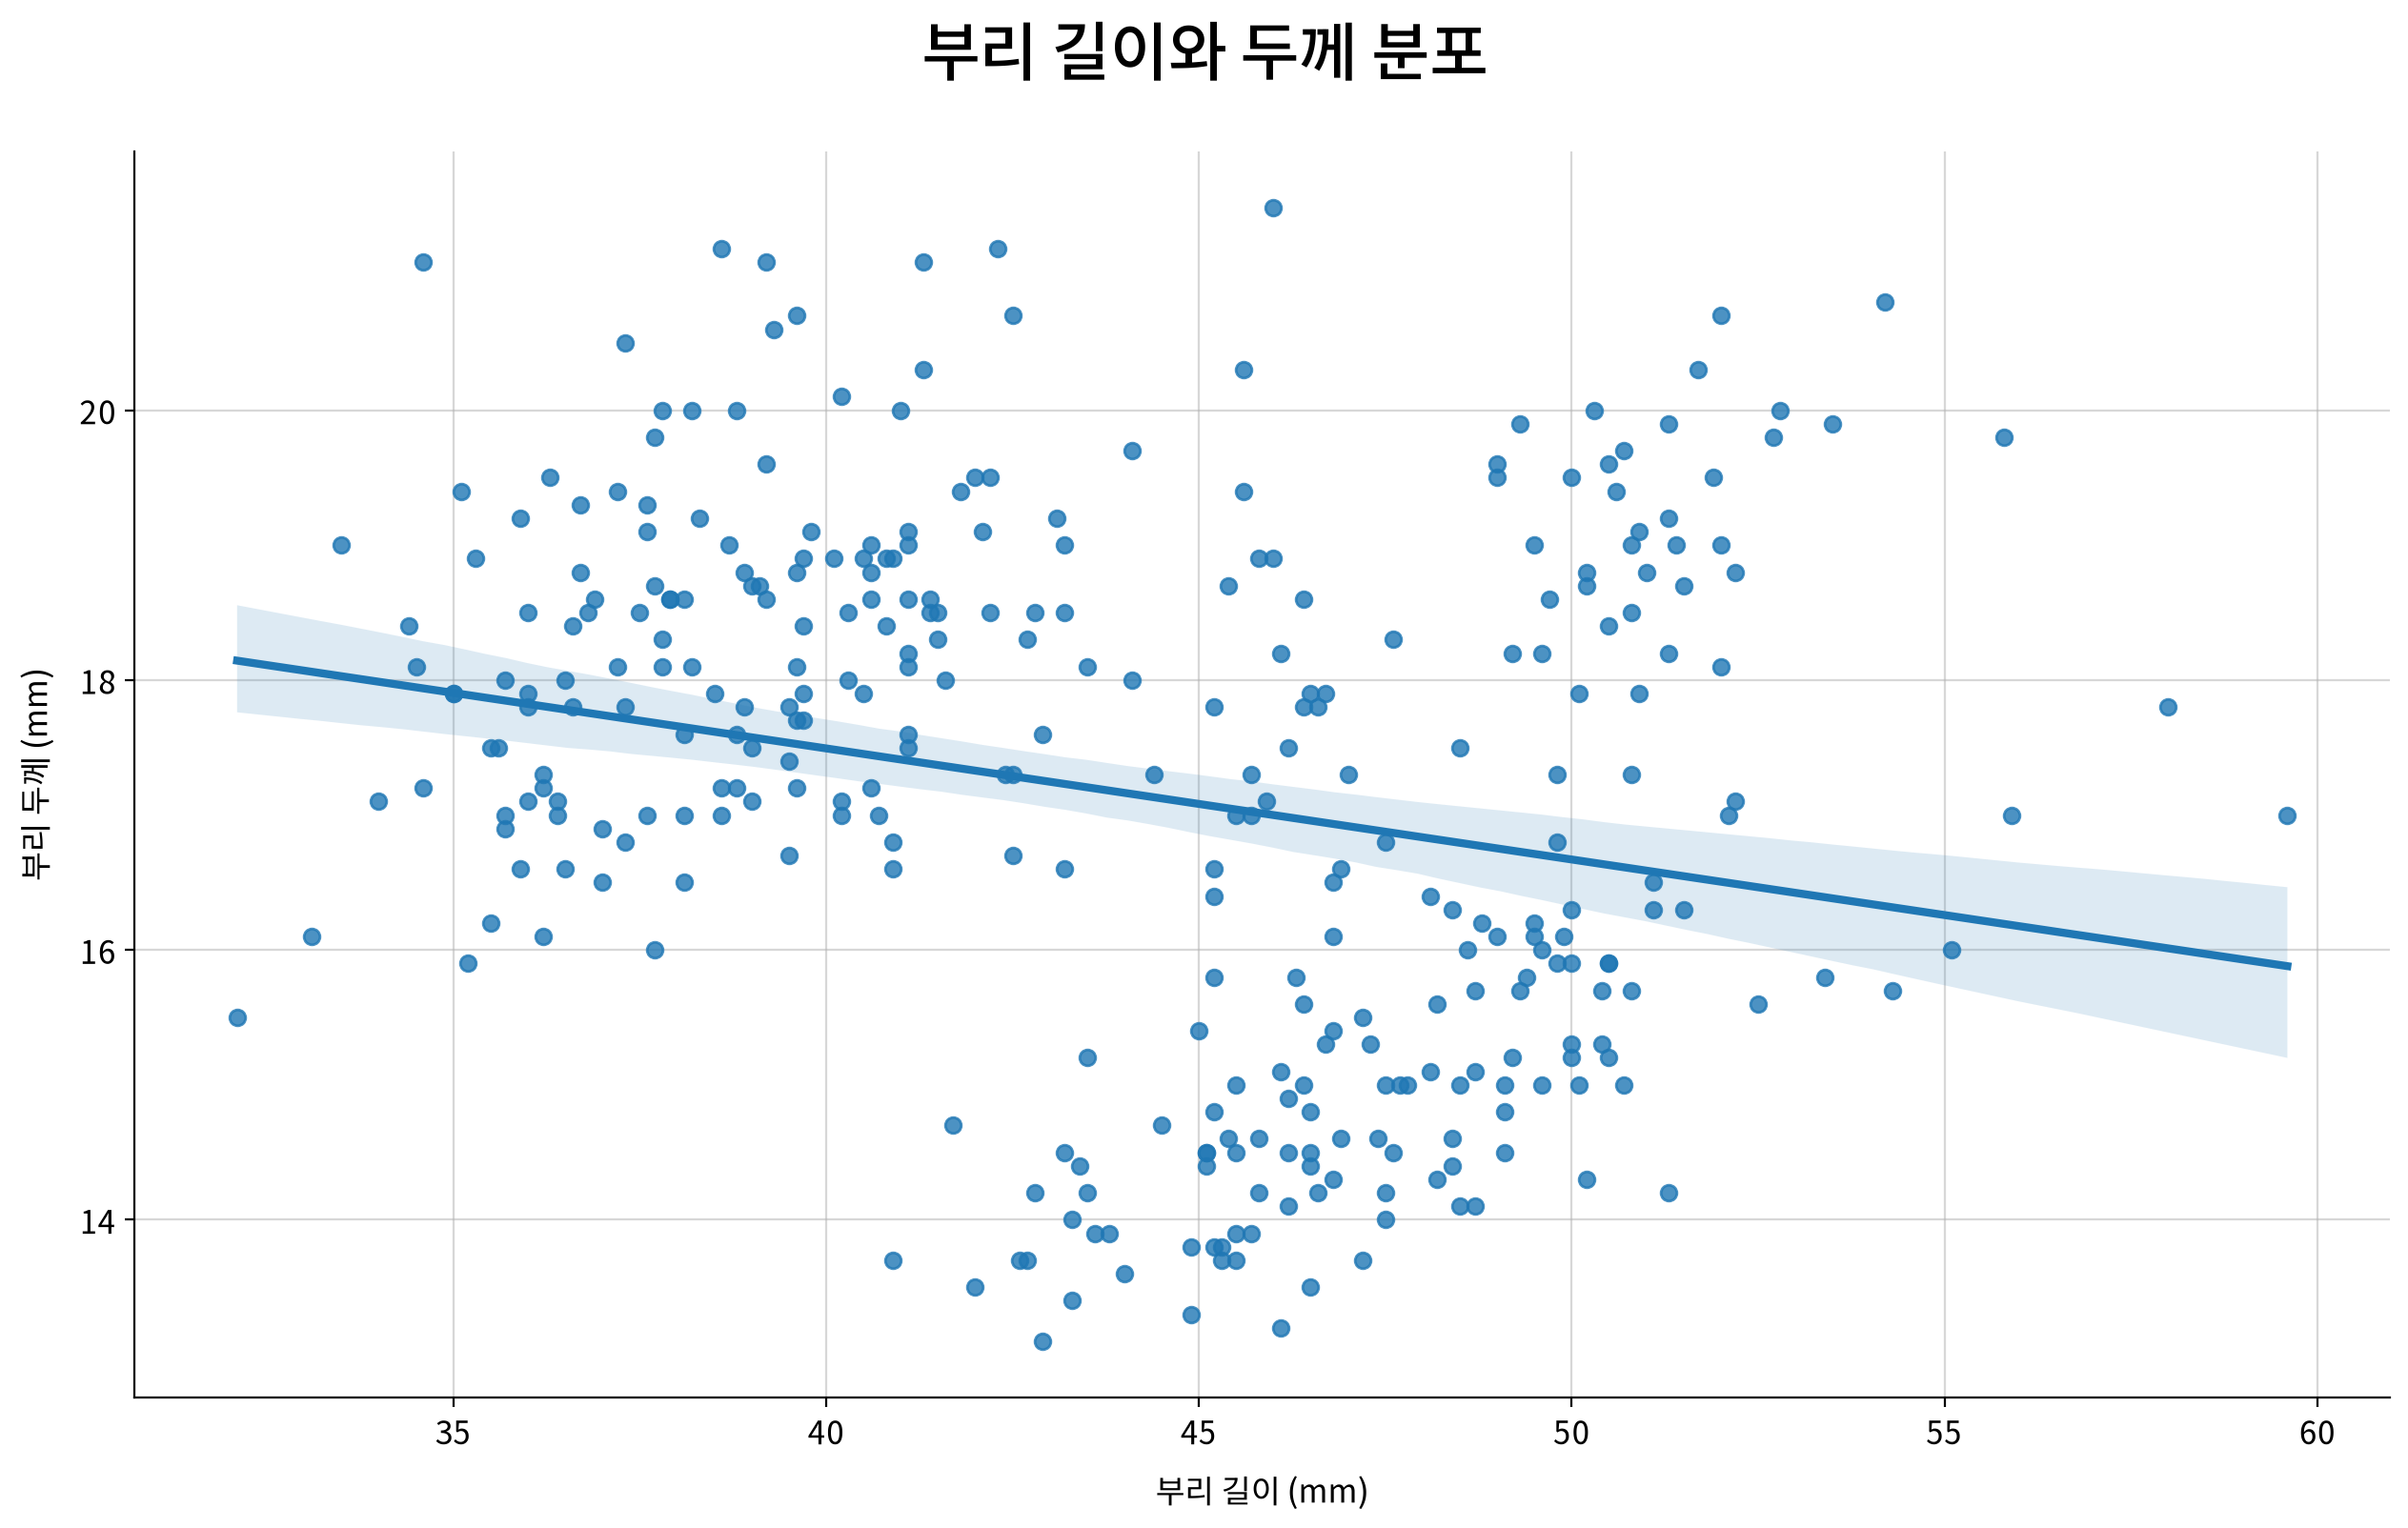

In [3]:
# 1) 그래프 초기화
width = 1280 / 100     # 그래프 가로 크기 1280 / 100
height = 800 / 100      # 그래프 세로 크기 800 / 100
my_dpi = 200            # 그래프 해상도 200

# 2) lmplot 그리기 --> 사이즈를 지정하는 방식이 독특하다
g = sb.lmplot(data=origin, x='bill_length_mm', y='bill_depth_mm', height=height, aspect=width/height)


# 3) 그래프 설정
g.fig.set_dpi(my_dpi)
g.fig.set_tight_layout(True)
g.fig.suptitle('부리 길이와 두께 분포', fontsize=24, fontweight=500, y=1)

# 4) ax 객체 추출 --> 리스트 형태로 추출된다.
ax = g.axes.flatten()
ax[0].set_xlabel('부리 길이 (mm)', fontsize=12, labelpad=10)
ax[0].set_ylabel('부리 두께 (mm)', fontsize=12, labelpad=10)
ax[0].grid(True, alpha=0.5)

# 5) 그래프 출력
my_plot.show()

#### 💡 인사이트

- 🔴 **음의 상관관계**: 부리 길이가 증가할수록 부리 두께가 감소하는 경향을 보임. 회귀선의 음의 기울기로 명확히 확인됨

- 📊 **선형성 강도**: 신뢰구간의 크기가 중간 정도로, 선형 관계가 존재하지만 개별 데이터의 편차가 상당함을 의미. 즉, 부리 길이만으로는 부리 두께를 완벽하게 예측할 수 없음

- 🎯 **데이터 범위 및 분포**:
  - 부리 길이: 약 33~62mm 범위에 분포
  - 부리 두께: 약 14~22mm 범위에 분포
  - 데이터 포인트들이 전체 범위에 걸쳐 비교적 고르게 분포

- 🔍 **회귀선의 신뢰도**: x축 중앙부(40~50mm)에서는 신뢰구간이 좁지만, 양쪽 끝(33mm, 62mm)으로 갈수록 신뢰구간이 넓어짐. 이는 극단값에서의 예측 불확실성이 높음을 의미

### 2. 그래프 마커 모양 설정하기

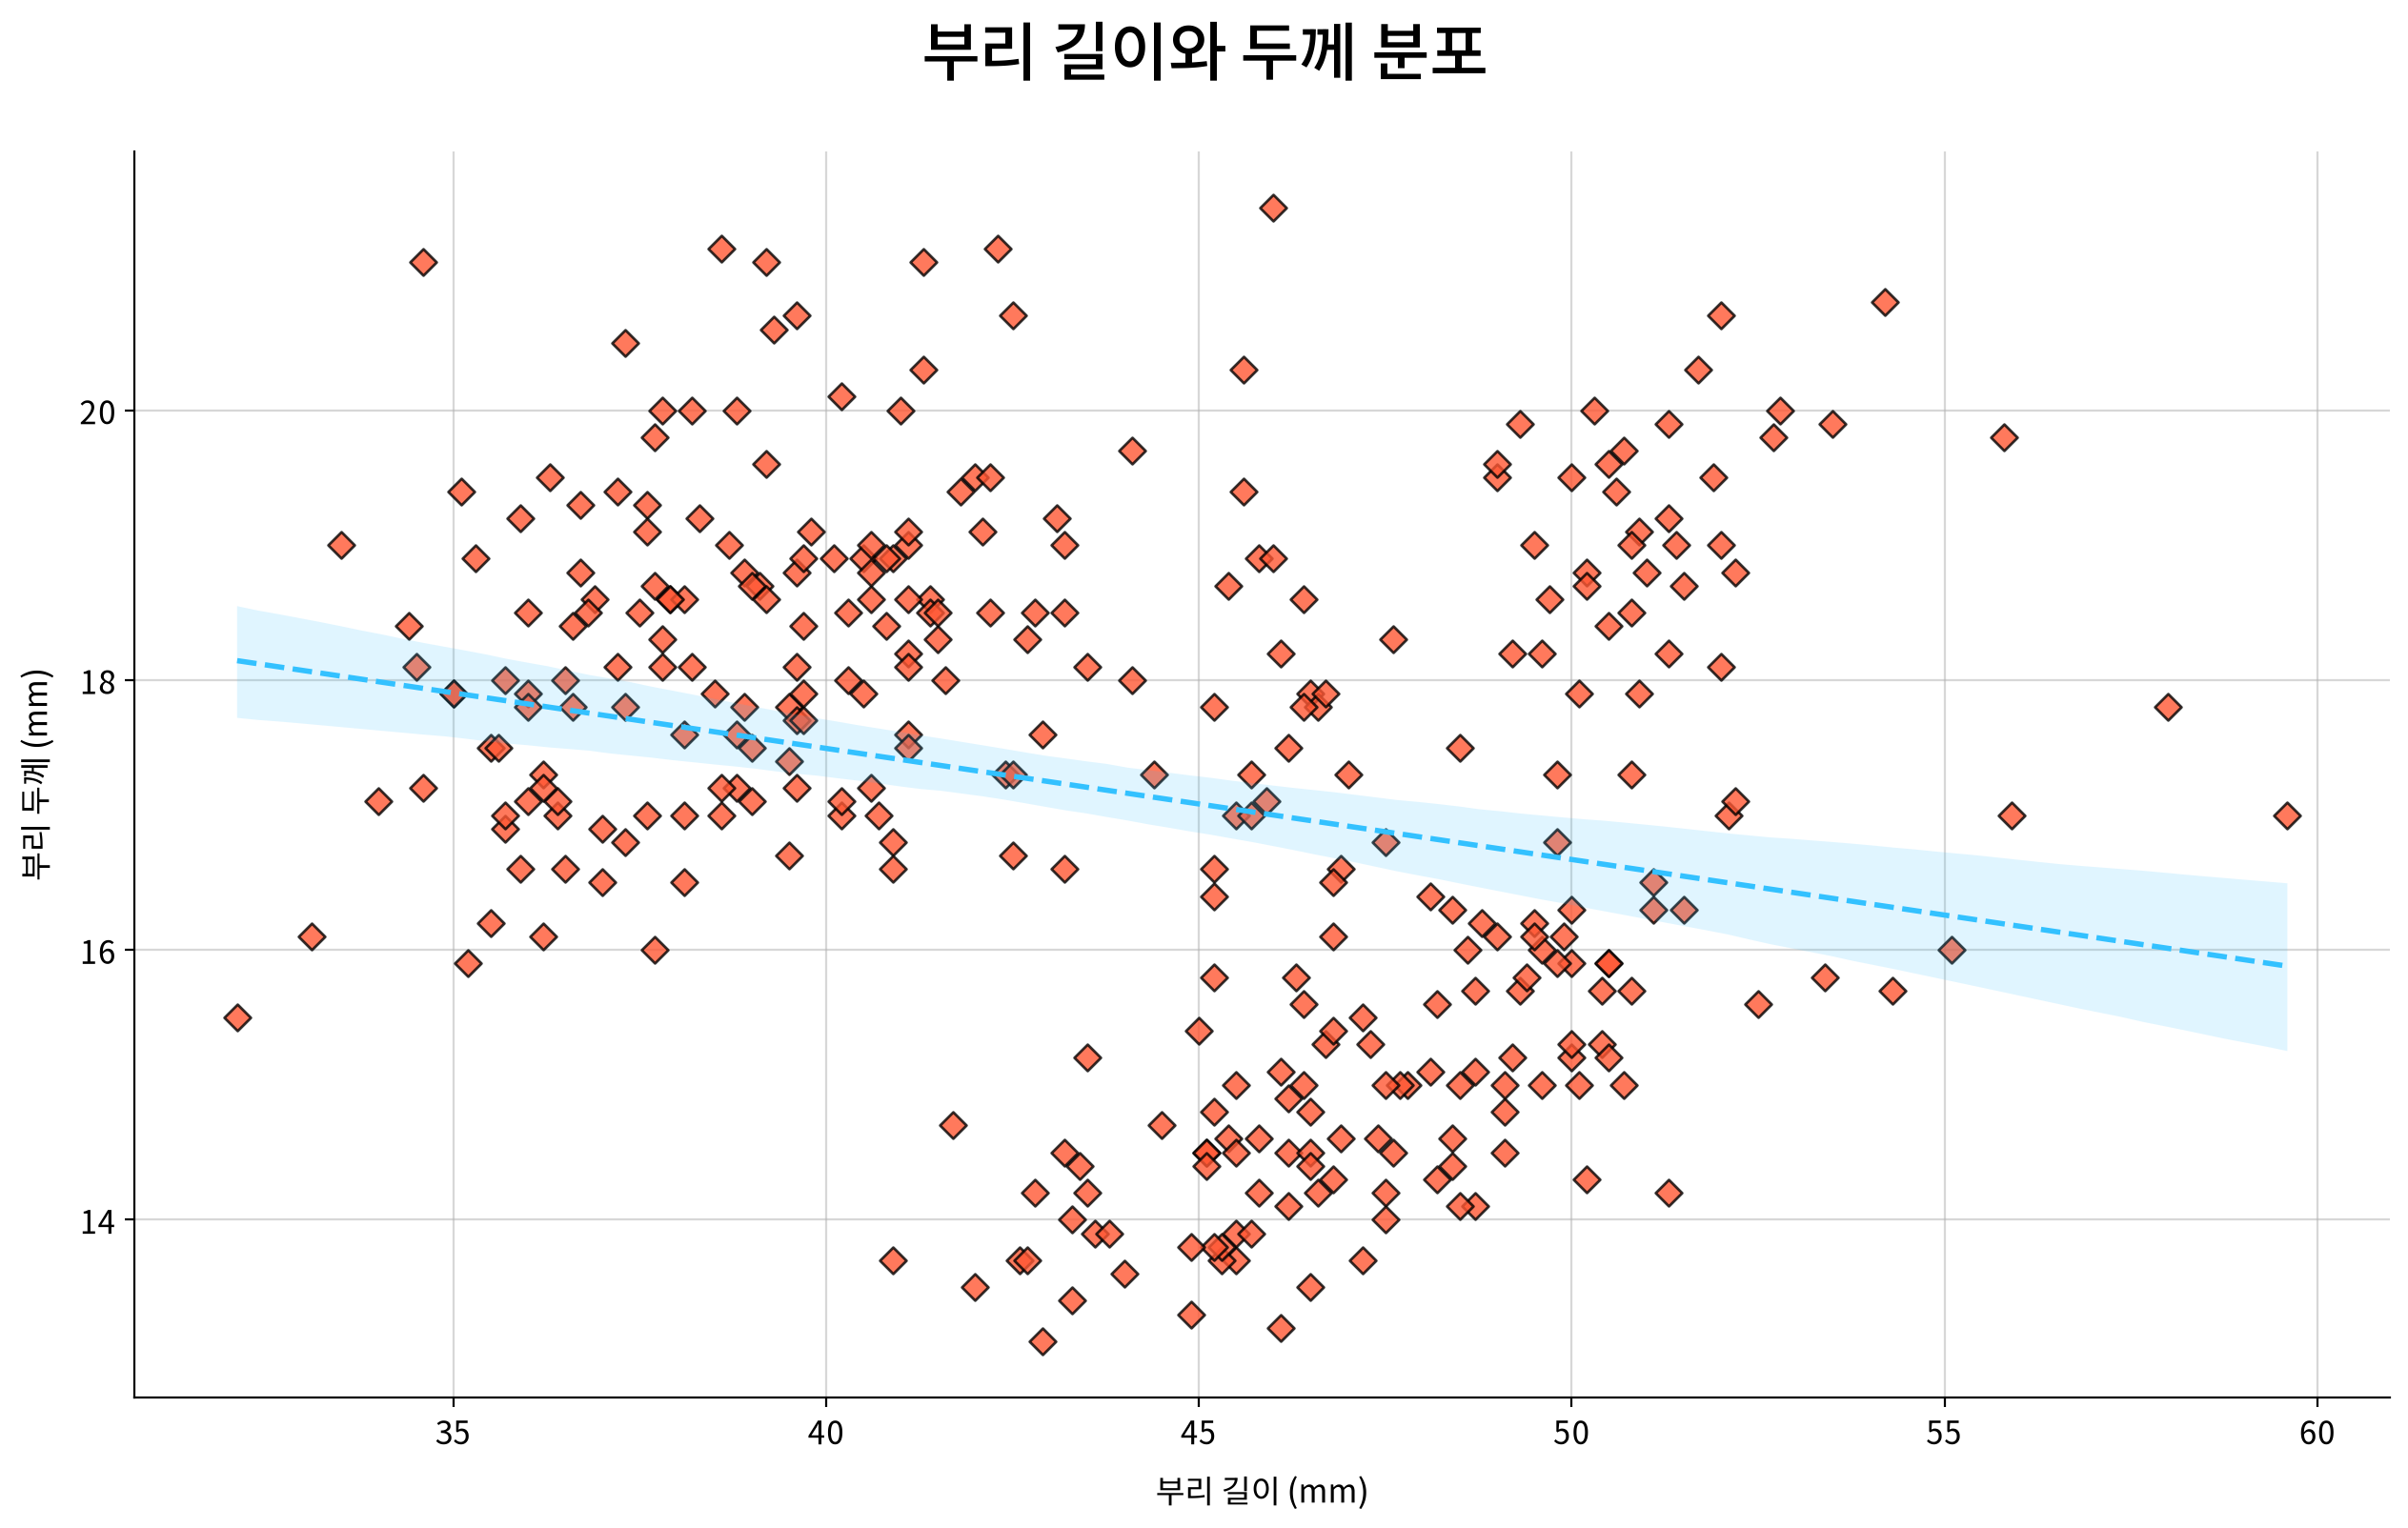

In [4]:
# 1) 그래프 초기화
width = 1280 / 100
height = 800 / 100
my_dpi = 200

# 2) lmplot 그리기 --> 사이즈를 지정하는 방식이 독특하다
g = sb.lmplot(data=origin, x='bill_length_mm', y='bill_depth_mm', 
              height=height, # 그래프 높이
              aspect=width/height, # 그래프 가로세로 비율
              markers="D",
              scatter_kws={
                  "edgecolor": "#000000",
                  "color": "#FF5733",
                  "linewidths": 1,
                  "s" : 50,
                  "alpha": 0.8,
              },
              line_kws={
                  "color": "#33C1FF",
                  "linestyle": "--",
                  "linewidth": 2,
              }
)

# 3) 그래프 설정
g.fig.set_dpi(my_dpi)
g.fig.set_tight_layout(True)
g.fig.suptitle('부리 길이와 두께 분포', fontsize=24, fontweight=500, y=1)

# 4) ax 객체 추출 --> 리스트 형태로 추출된다.
ax = g.axes.flatten()
ax[0].set_xlabel('부리 길이 (mm)', fontsize=12, labelpad=10)
ax[0].set_ylabel('부리 두께 (mm)', fontsize=12, labelpad=10)
ax[0].grid(True, alpha=0.5)

# 5) 그래프 출력
my_plot.show()

### 3. 범주 설정하기 - 종별 부리 길이와 부리 두께의 관계 

- 앞 단계의 코드를 복사한 후 수정하세요

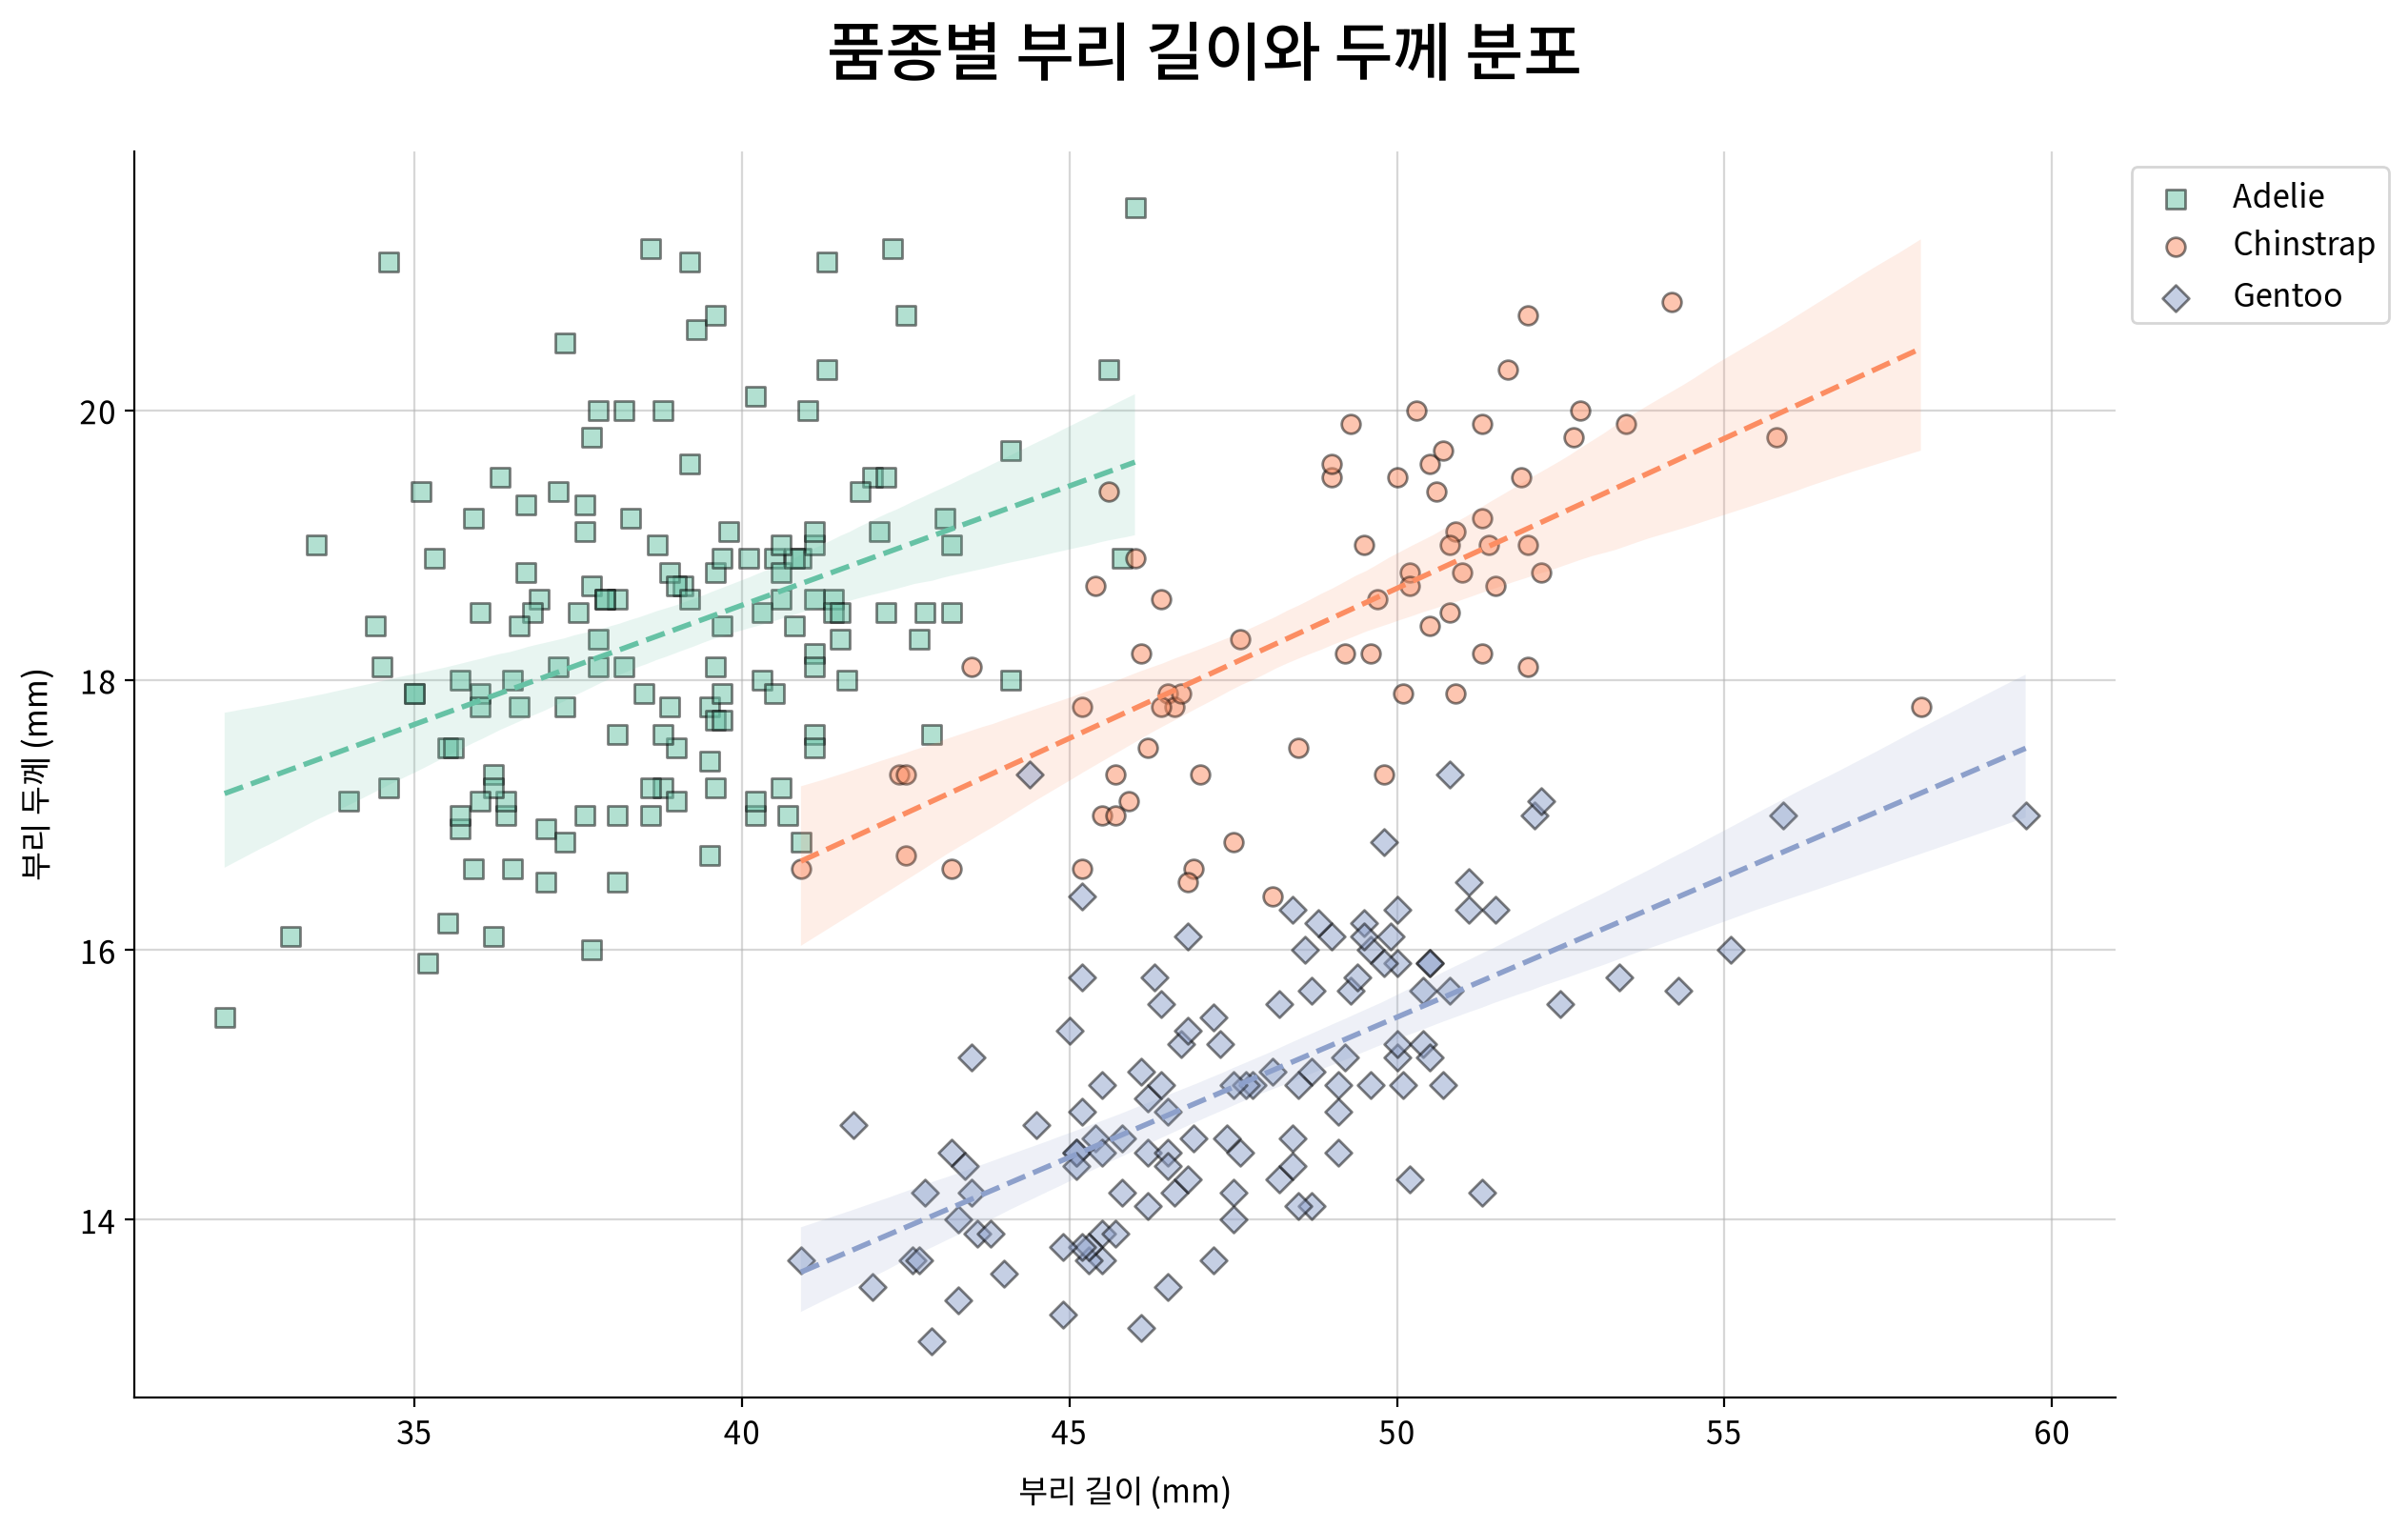

In [5]:
# 1) 그래프 초기화
width = 1280 / 100
height = 800 / 100
my_dpi = 200

# 2) lmplot 그리기 --> 사이즈를 지정하는 방식이 독특하다
g = sb.lmplot(data=origin, x='bill_length_mm', y='bill_depth_mm', height=height, aspect=width/height,
              hue='species',
              legend=False,
              markers= ["s", "o", "D"],
              palette="Set2",
              scatter_kws={
                  "edgecolor": "#000000",
                  "linewidths": 1,
                  "s" : 50,
                  "alpha" : 0.5,
              },
              line_kws={
                  "linestyle": "--",
                  "linewidth": 2,
              })

# 3) 그래프 설정
g.fig.set_dpi(my_dpi)
g.fig.set_tight_layout(True)
g.fig.suptitle('품종별 부리 길이와 두께 분포', fontsize=24, fontweight=500, y=1)

# 4) ax 객체 추출 --> 리스트 형태로 추출된다.
ax = g.axes.flatten()
ax[0].set_xlabel('부리 길이 (mm)', fontsize=12, labelpad=10)
ax[0].set_ylabel('부리 두께 (mm)', fontsize=12, labelpad=10)
ax[0].grid(True, alpha=0.5)
ax[0].legend(bbox_to_anchor=(1,1), loc='upper left')

# 5) 그래프 출력
my_plot.show()

#### 💡 인사이트

- 🐧 **종별 상반된 관계**: 종을 구분하지 않으면 음의 상관관계이지만, 종별로 분석하면 대부분 양의 상관관계를 보임

- 📍 **종별 특성 차이**:
  - **Adelie (녹색)**: 부리 길이 33~46mm, 부리 두께 17~20.5mm 범위 - 양의 상관관계
  - **Chinstrap (주황)**: 부리 길이 46~58mm, 부리 두께 17~20.5mm 범위 - 강한 양의 상관관계
  - **Gentoo (파랑)**: 부리 길이 46~61mm, 부리 두께 13.5~17.5mm 범위 - 약한 양의 상관관계

- 📈 **회귀선의 기울기 비교**: Chinstrap의 회귀선 기울기가 가장 가파르고, Gentoo의 기울기가 가장 완만함. 이는 종마다 부리 길이 증가에 따른 두께 변화의 정도가 다름을 의미

### 4. 열 구분하기 - 성별에 따른 종별 부리 길이와 부리 두께의 관계

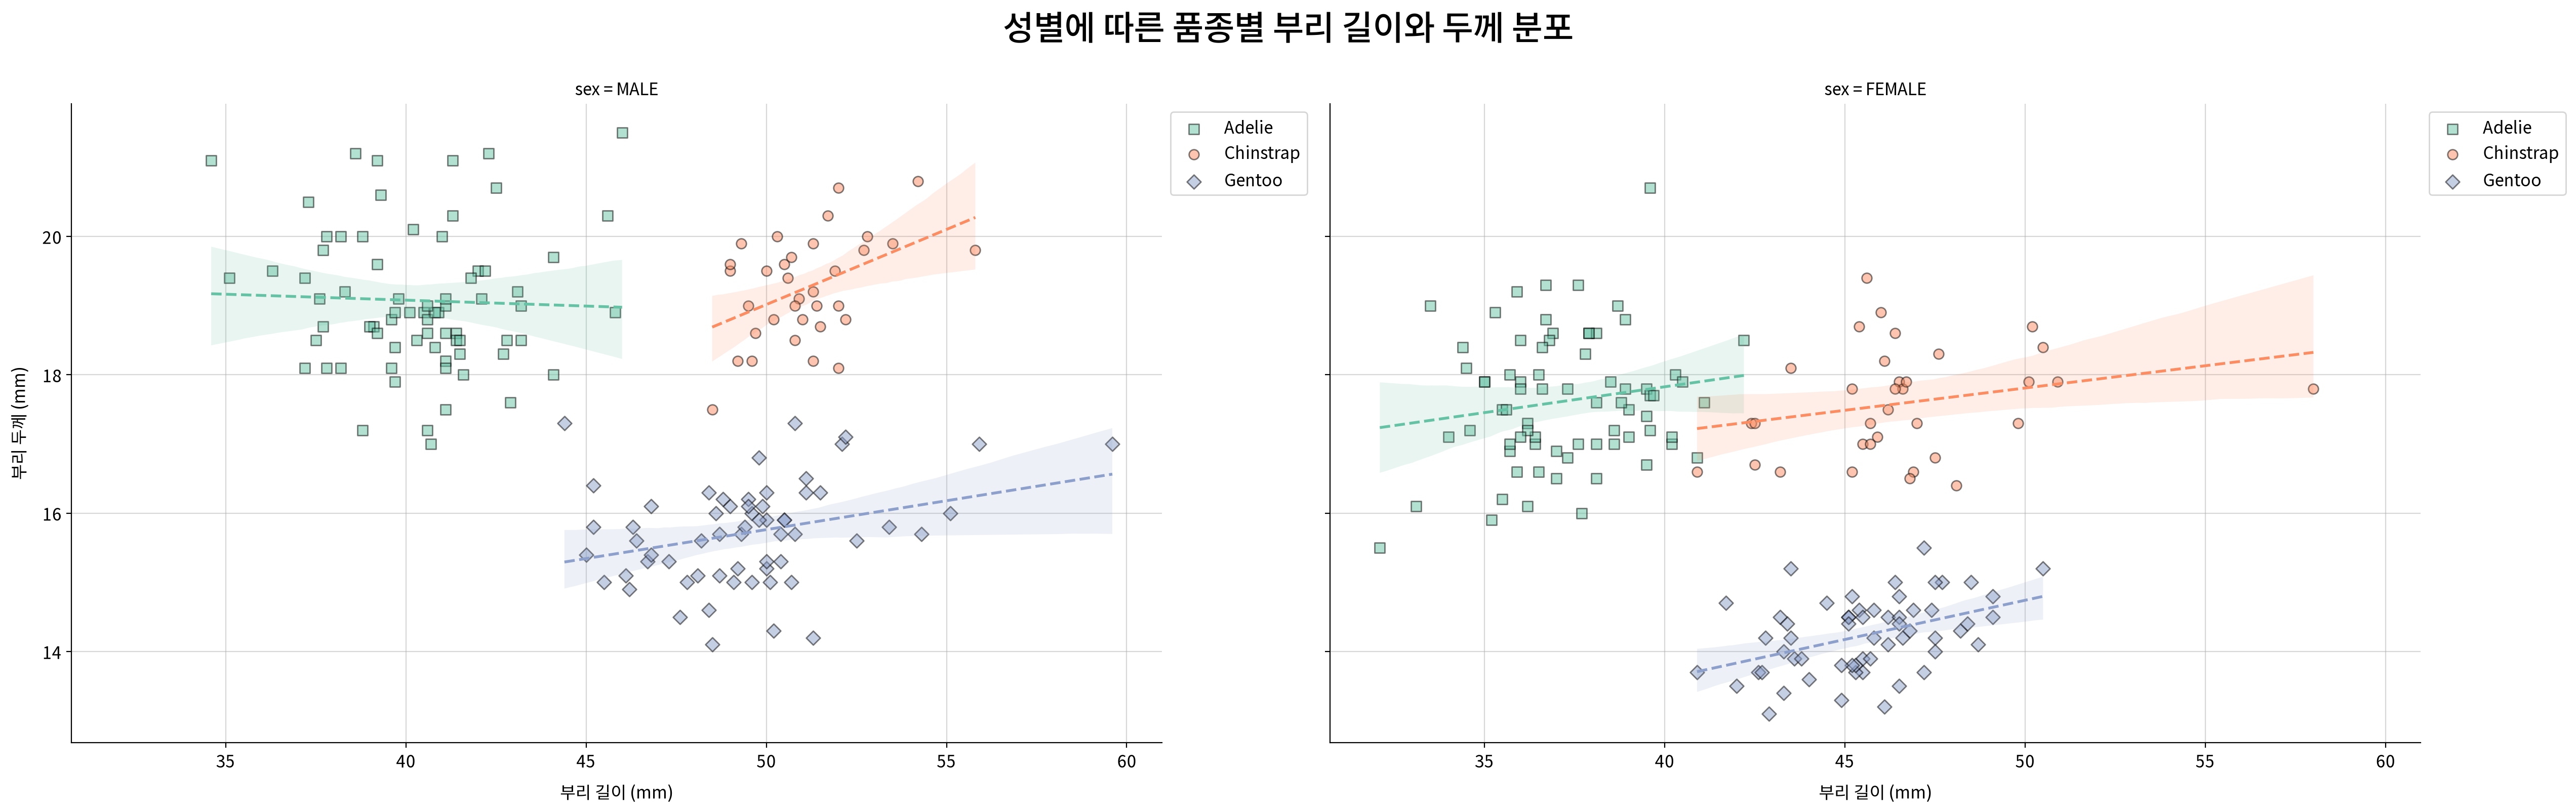

In [6]:
# 1) 그래프 초기화 -> pyplot 객체를 직접 초기화 할 수 없음 (my_plot.init()을 쓸수 없음)


# 2) lmplot 그리기 --> 사이즈를 지정하는 방식이 독특하다
g = sb.lmplot(data=origin, x='bill_length_mm', y='bill_depth_mm', height=height, aspect=width/height,
              hue='species',
              col = 'sex',
              legend=False,
              markers= ["s", "o", "D"],
              palette="Set2",
              scatter_kws={
                  "edgecolor": "#000000",
                  "linewidths": 1,
                  "s" : 50,
                  "alpha" : 0.5,
              },
              line_kws={
                  "linestyle": "--",
                  "linewidth": 2,
              })

# 3) 그래프 설정
g.fig.set_dpi(my_dpi)           # 그래프 해상도 설정
g.fig.set_tight_layout(True)    # 여백 제거
g.fig.suptitle('성별에 따른 품종별 부리 길이와 두께 분포', fontsize=24, fontweight=500, y=1)

# 4) ax 객체 추출 --> 그래프가 2열로 분할되어 있기 때문에 ax[0]과 ax[1]에 각각 접근해야 한다.
ax = g.axes.flatten()

# 반복문을 사용하여 분할된 그래프 각각에 레이블과 범례, 그리드 설정
for a in ax:
    a.set_xlabel('부리 길이 (mm)', fontsize=12, labelpad=10)
    a.set_ylabel('부리 두께 (mm)', fontsize=12, labelpad=10)
    a.legend(bbox_to_anchor=(1, 1), loc='upper left') # 범례 위치 조정
    a.grid(True, alpha=0.5)

# 5) 그래프 출력
my_plot.show()

#### 💡 인사이트

- 🚹🚺 **성별에 따른 부리 특성 차이**: 남성 개체가 여성 개체보다 전반적으로 부리 길이가 크고 두께도 더 큼. 이는 종 내에서 성별에 따른 신체 크기 차이 현상

- 📊 **성별별 종 구분의 명확성**:
  - **남성**: Adelie(좌상단), Chinstrap(우상단), Gentoo(중앙하단)이 비교적 뚜렷하게 분리됨
  - **여성**: 종 간 겹침이 많아서 구분이 덜 명확함. 특히 Adelie와 Chinstrap이 중첩 영역 존재

- 📈 **성별에 따른 상관관계의 강도 차이**: 
  - **남성**: Chinstrap의 회귀선 기울기가 가장 가파르고, 신뢰구간이 대체로 좁음 → 종 내 관계가 더 선형적
  - **여성**: 전체적으로 신뢰구간이 넓고 기울기가 완만함 → 개체 간 변동성이 더 큼

- 🎯 **성별 추가 변수의 중요성**: 같은 종이라도 성별에 따라 회귀선의 위치와 기울기가 달라짐. 따라서 생물학적 특성 분석 시 성별은 결과에 영향을 미치는 숨은 변수로 반드시 고려해야 함

## #03. 모듈화 기능 확인

### 1. 기본 산점도

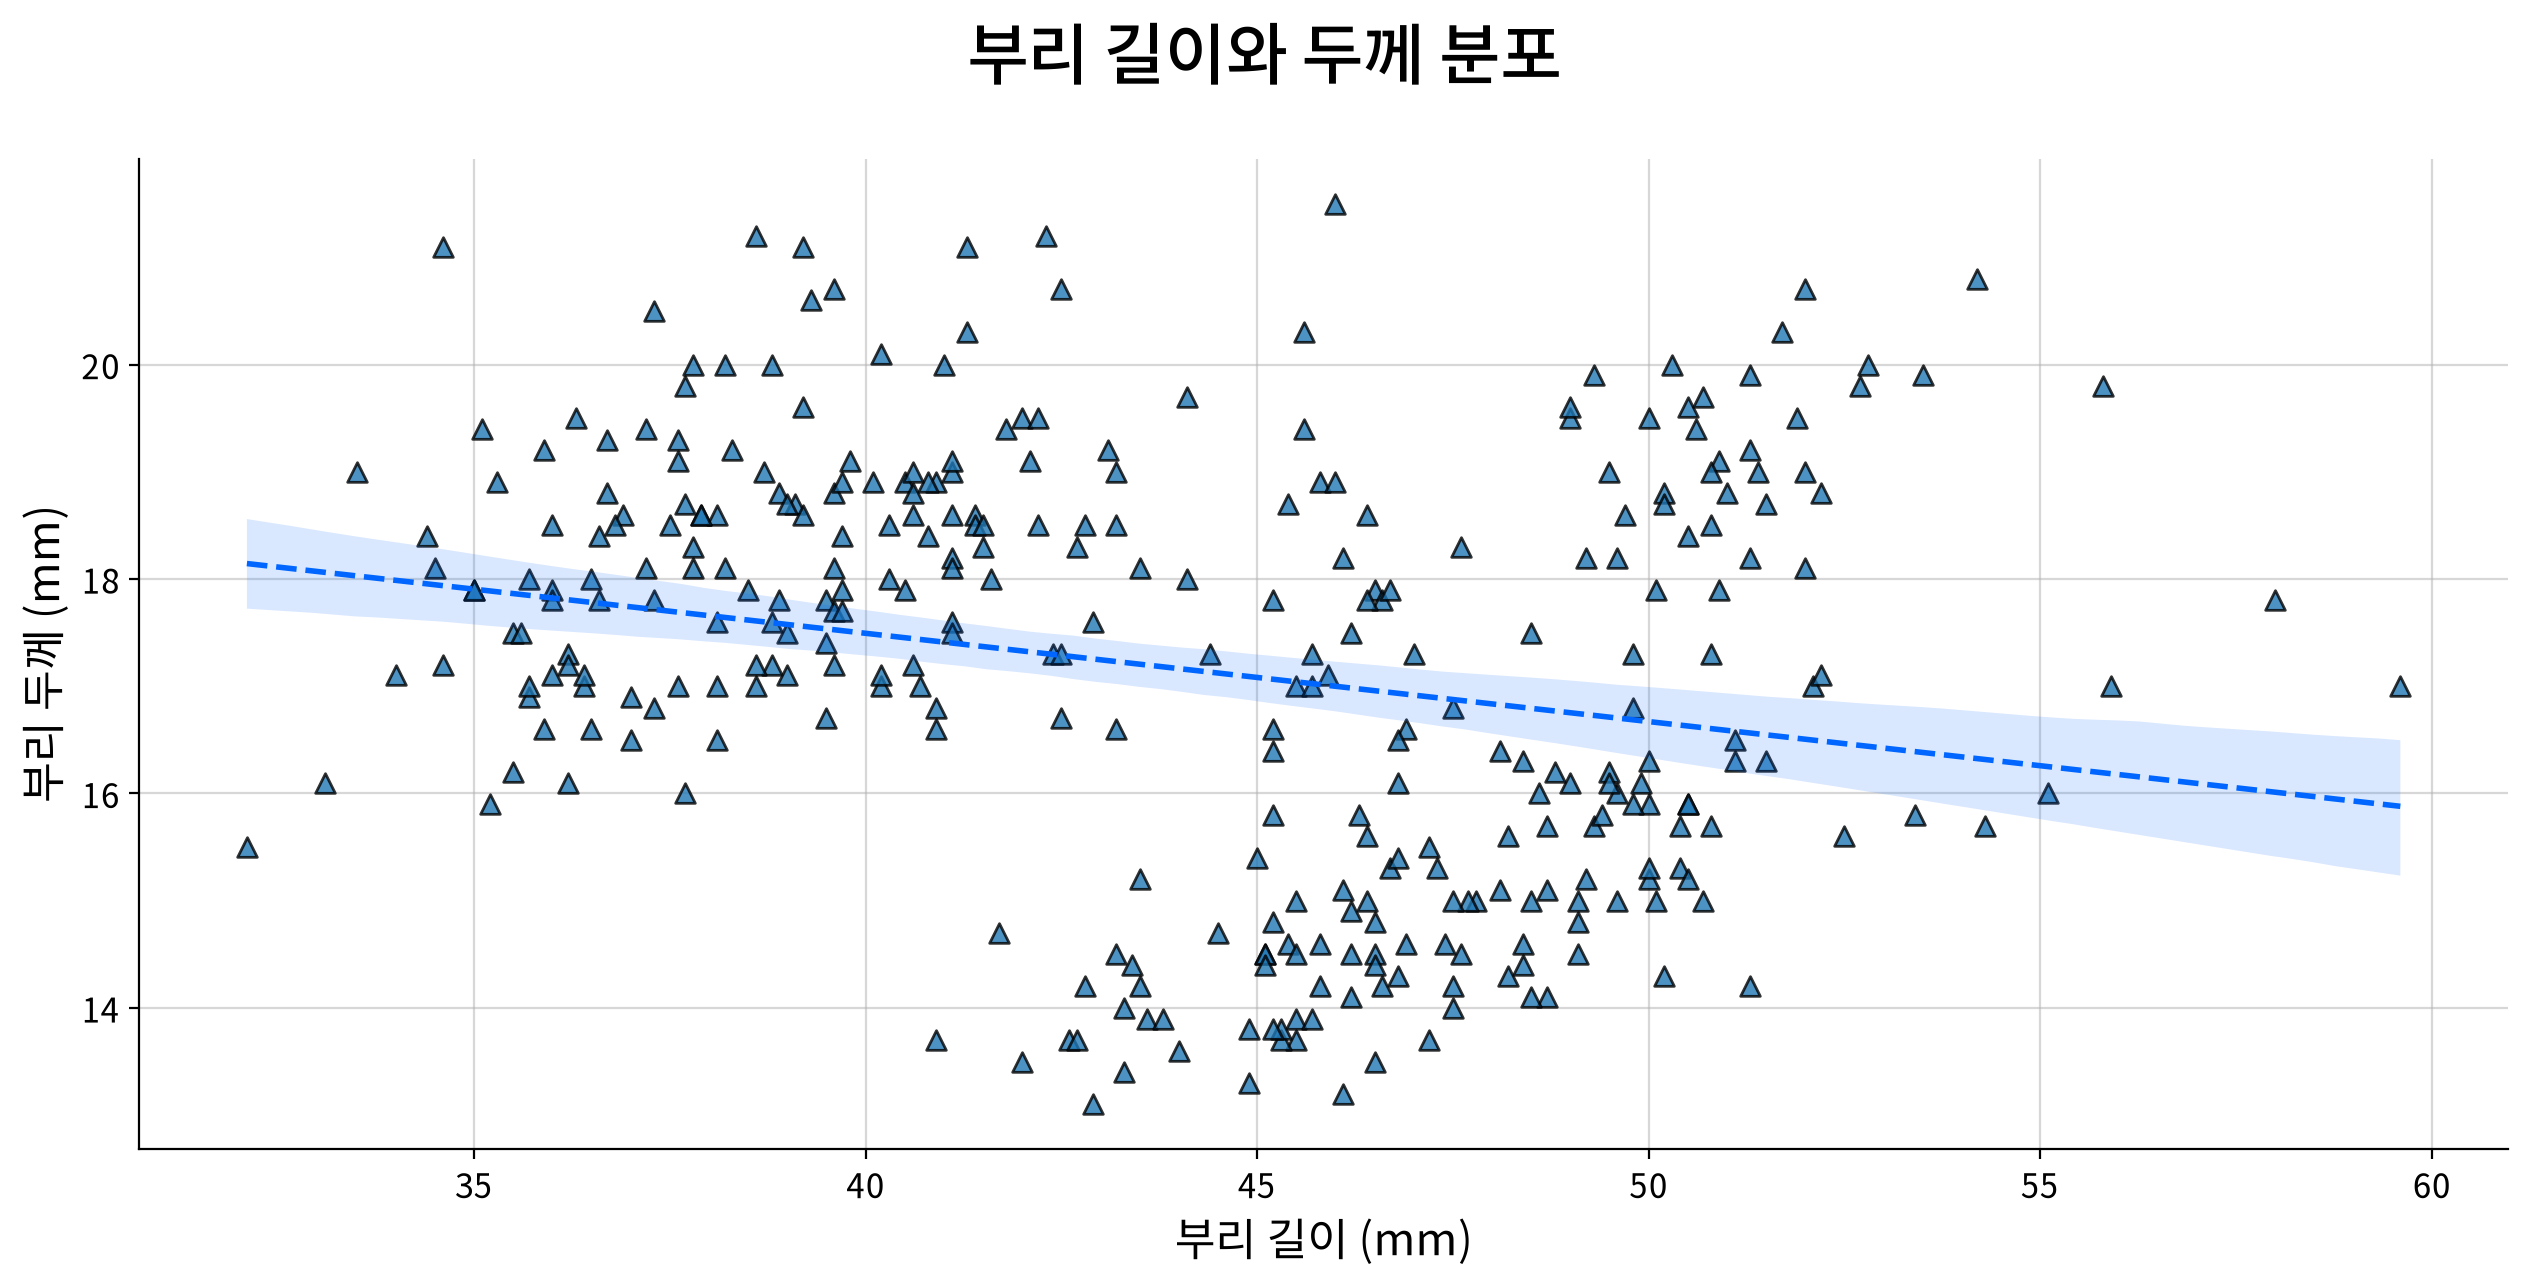

In [7]:
my_plot.lmplot(data=origin, x='bill_length_mm',  y='bill_depth_mm',
                title='부리 길이와 두께 분포',
                xlabel='부리 길이 (mm)', ylabel='부리 두께 (mm)',
                markers="^", 
                scatter_edgecolor="#000000", scatter_linewidths=1, scatter_size=50,
                linestyle="--", linecolor="#0066ff", linewidth=2)

### 2. 범주별 산점도

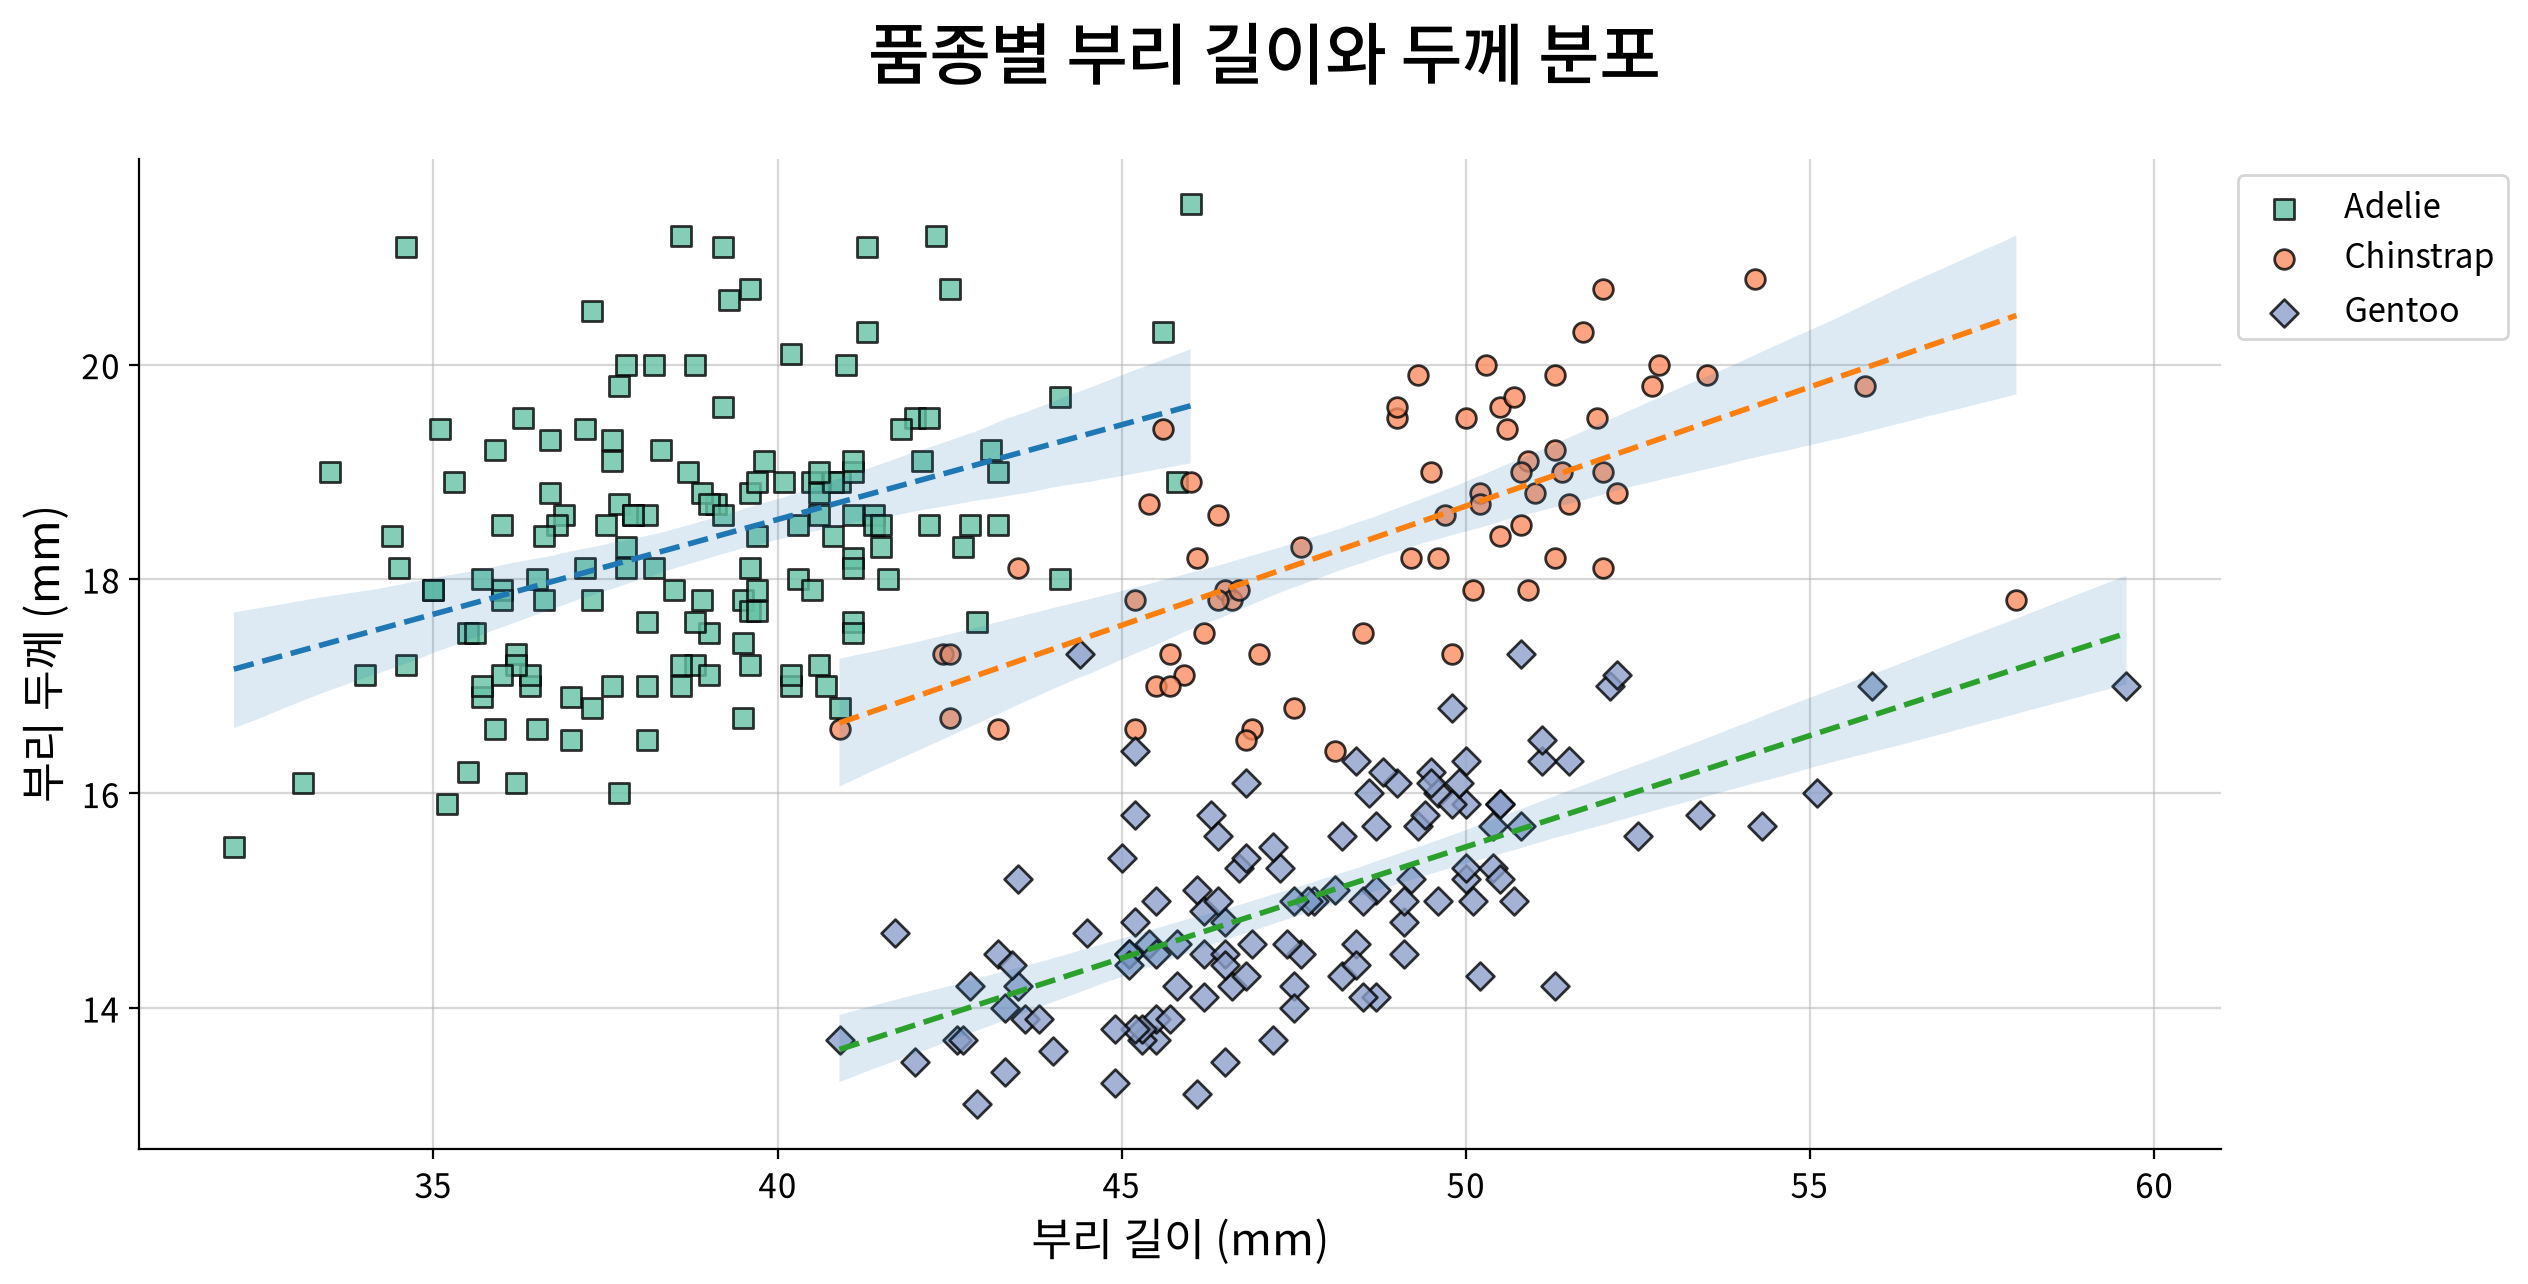

In [8]:
my_plot.lmplot(data=origin, x='bill_length_mm',  y='bill_depth_mm',
                title='품종별 부리 길이와 두께 분포',
                xlabel='부리 길이 (mm)', ylabel='부리 두께 (mm)',
                hue='species', palette="Set2", 
                markers=["s", "o", "D"], 
                scatter_edgecolor="#000000", scatter_linewidths=1, scatter_size=50,
                linestyle="--", linewidth=2)

### 3. 열로 구별된 범주별 산점도

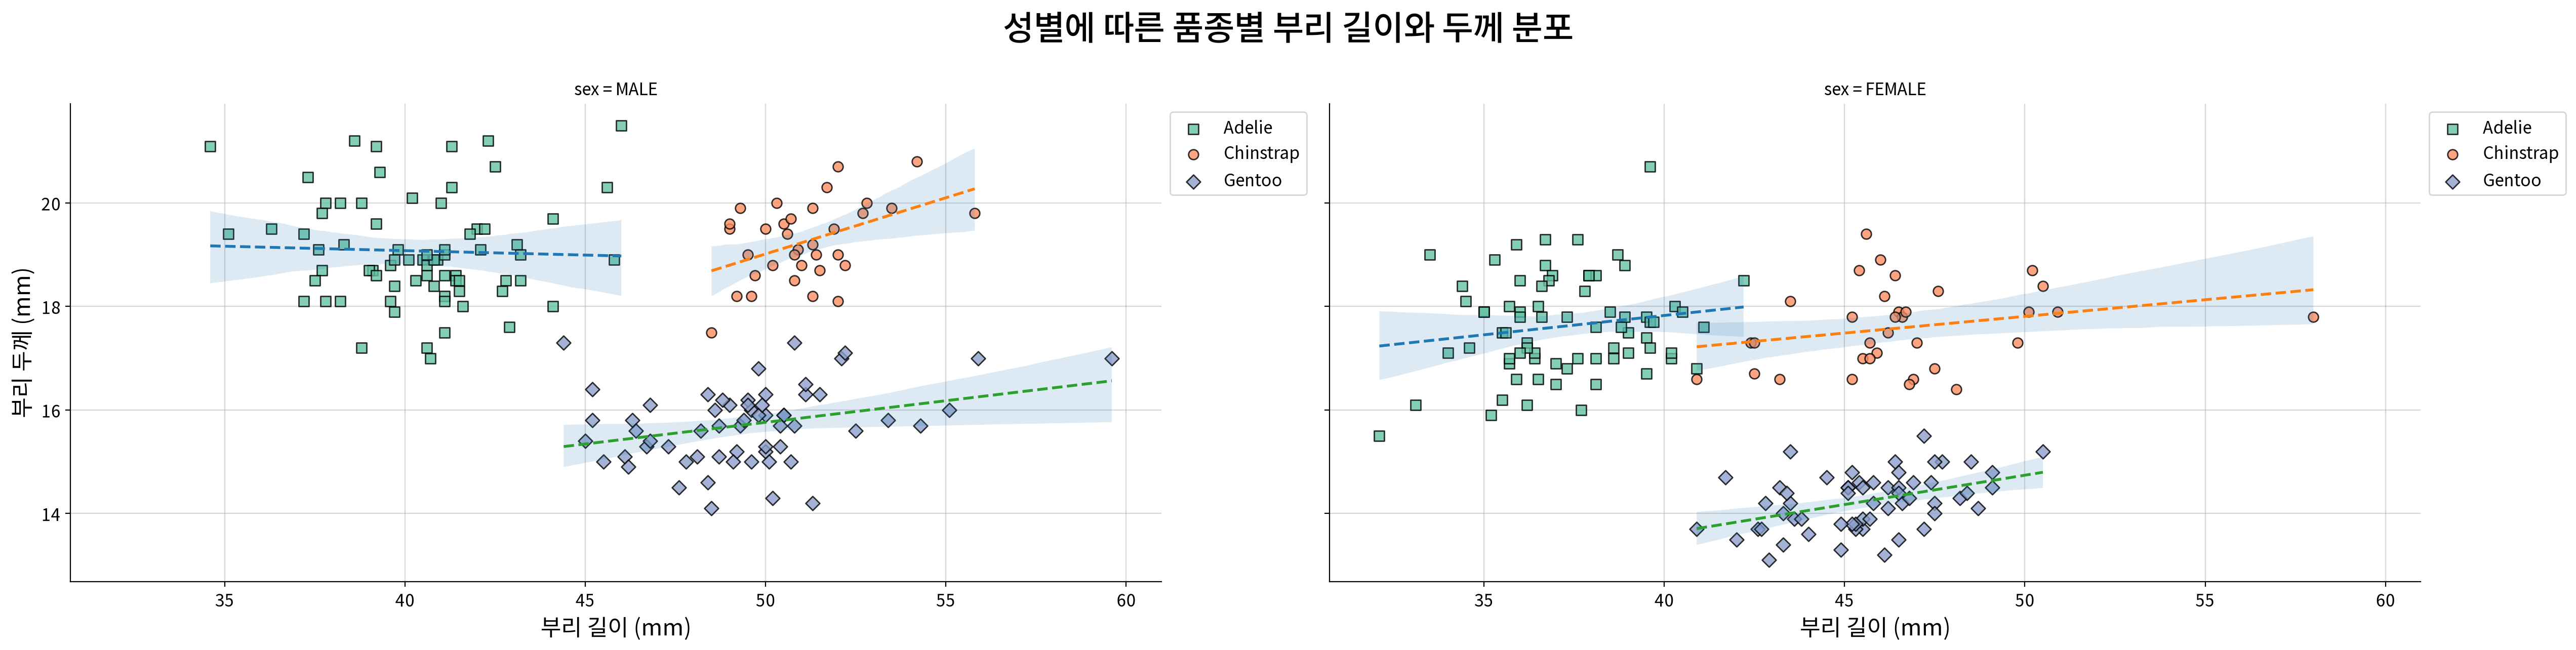

In [9]:
my_plot.lmplot(data=origin, x='bill_length_mm',  y='bill_depth_mm',
                title='성별에 따른 품종별 부리 길이와 두께 분포',
                xlabel='부리 길이 (mm)', ylabel='부리 두께 (mm)',
                hue='species', palette="Set2", col="sex",
                markers=["s", "o", "D"], 
                scatter_edgecolor="#000000", scatter_linewidths=1, scatter_size=50,
                linestyle="--", linewidth=2)

### 연습문제. 녹지가 많은 동네는 정말 월세가 비쌀까?
#### 데이터 셋 : city_districts
#### 회귀선이 포함된 산점도로 이 가설을 검증하고, 보고서에 넣을 인사이트 정리

In [10]:
# 필요한 모듈 불러오기
from jussam import load_data
from helper import my_plot
import seaborn as sb

In [12]:
# 0. 데이터 불러오기
df = load_data('city_districts')
df.info()
df

📚 전국 자치구의 녹지율과 평균월세에 대한 가상의 데이터
<class 'pandas.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   권역      330 non-null    str    
 1   도시규모    330 non-null    str    
 2   녹지율     330 non-null    float64
 3   인구밀도    330 non-null    int64  
 4   평균월세    330 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 19.4 KB


,권역,도시규모,녹지율,인구밀도,평균월세
0,수도권,중소도시,11.500,17670,108.300
1,영남권,대도시,24.400,12610,98.500
2,호남권,중소도시,29.100,1310,70.300
3,호남권,대도시,29.200,4710,73.900
4,영남권,대도시,19.200,10900,86.600
...,...,...,...,...,...
325,영남권,중소도시,14.800,6300,74.700
326,수도권,대도시,6.300,21430,112.300
327,수도권,중소도시,15.000,17240,109.200
328,영남권,대도시,17.800,11140,92.200


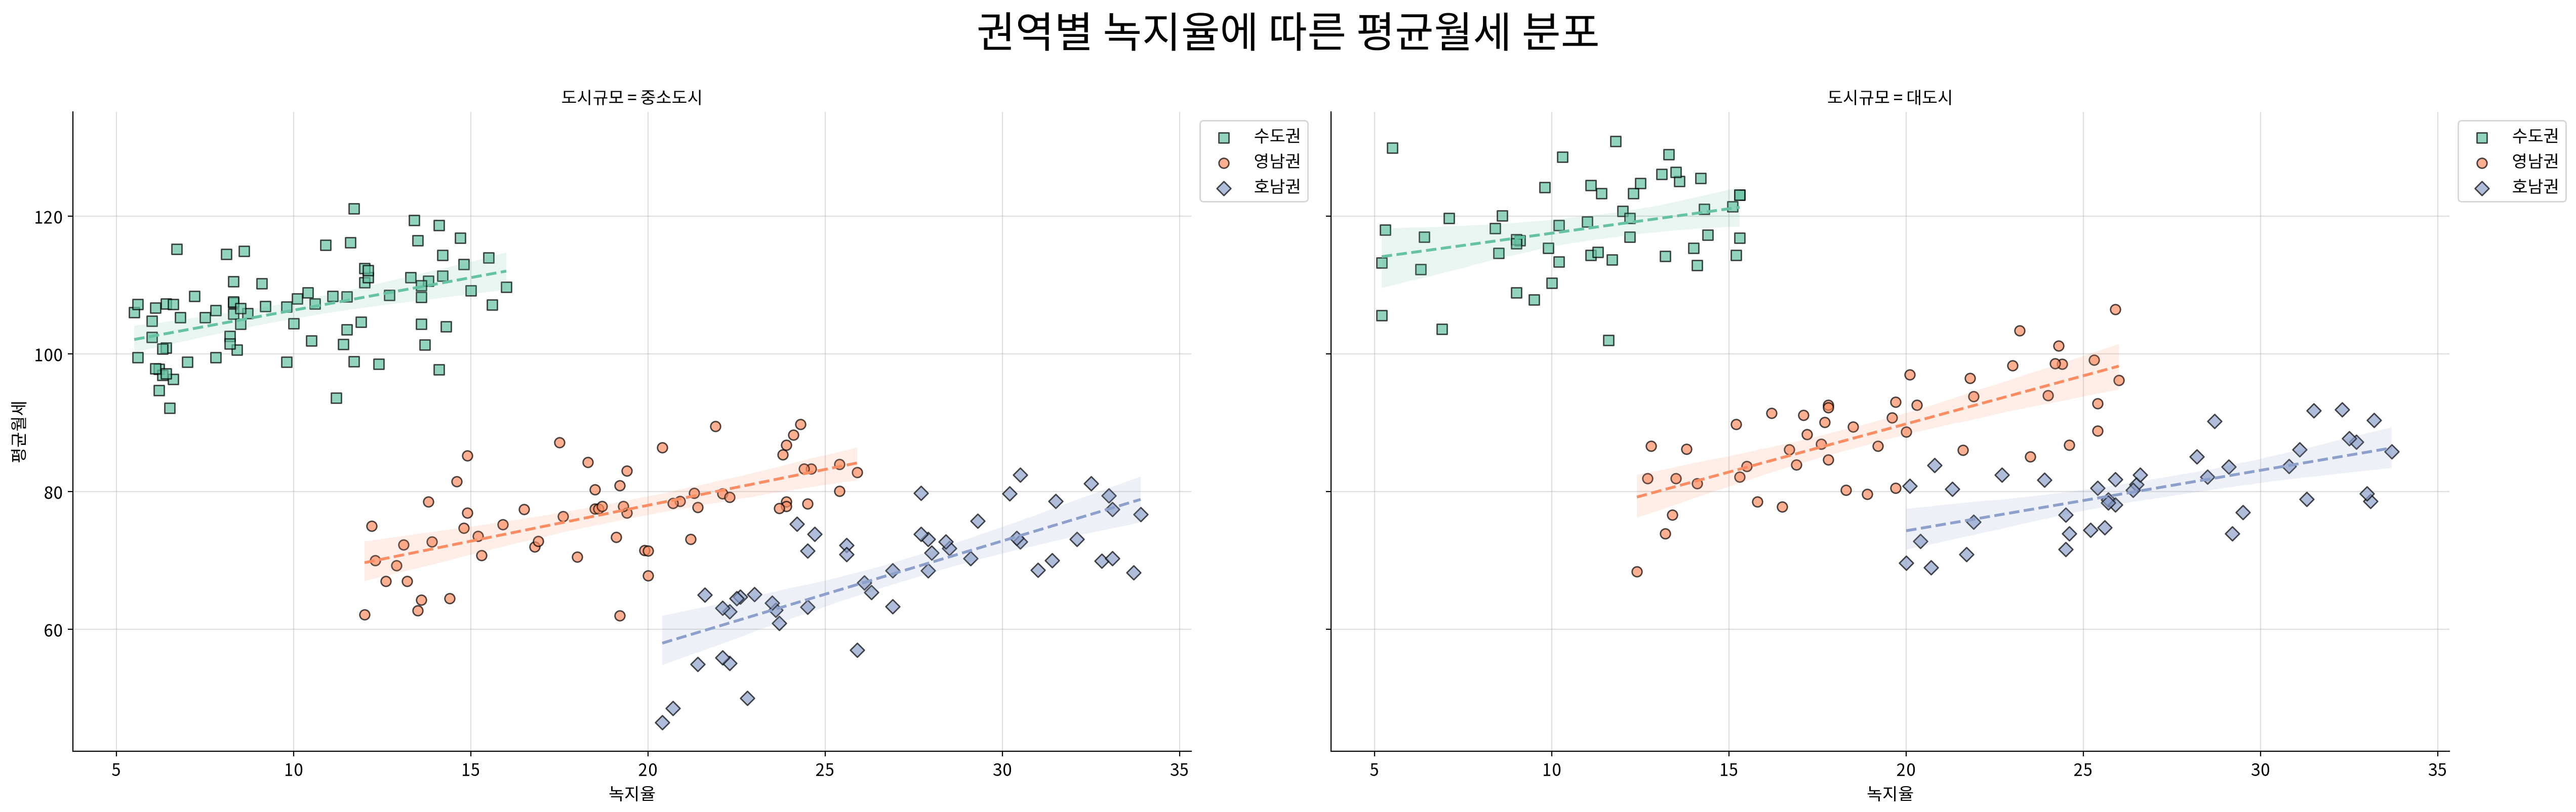

In [16]:
# 1. 산점도 그리기 (녹지율에 따른 평균월세) (모듈사용X)
# 1). 그래프 초기화
width = 1280 / 100
height = 800 / 100
my_dpi = 200

# 2). lmplot
g = sb.lmplot(data=df, x="녹지율", y="평균월세", height=height, aspect=width/height, hue="권역", col="도시규모", legend=False,
              markers=["s", "o", "D"],
              palette="Set2",
              scatter_kws={
                "edgecolor": "#000000",
                "linewidths": 1,
                "s": 50,
                "alpha": 0.7,
              },
              line_kws={
                  "linestyle": "--",
                  "linewidth": 2,
              })
# 3). 그래프 설정
g.fig.set_dpi(my_dpi)
g.fig.set_tight_layout(True)
g.fig.suptitle('권역별 녹지율에 따른 평균월세 분포', fontsize=30, fontweight=400, y=1)

# 4). ax 객체 추출
ax = g.axes.flatten()

for a in ax:
  a.set_xlabel("녹지율", fontsize=12, labelpad=5)
  a.set_ylabel("평균월세", fontsize=12, labelpad=5)
  a.grid(True, alpha=0.4)
  a.legend(bbox_to_anchor=(1,1), loc='upper left')

# 5). 그래프 출력
my_plot.show()

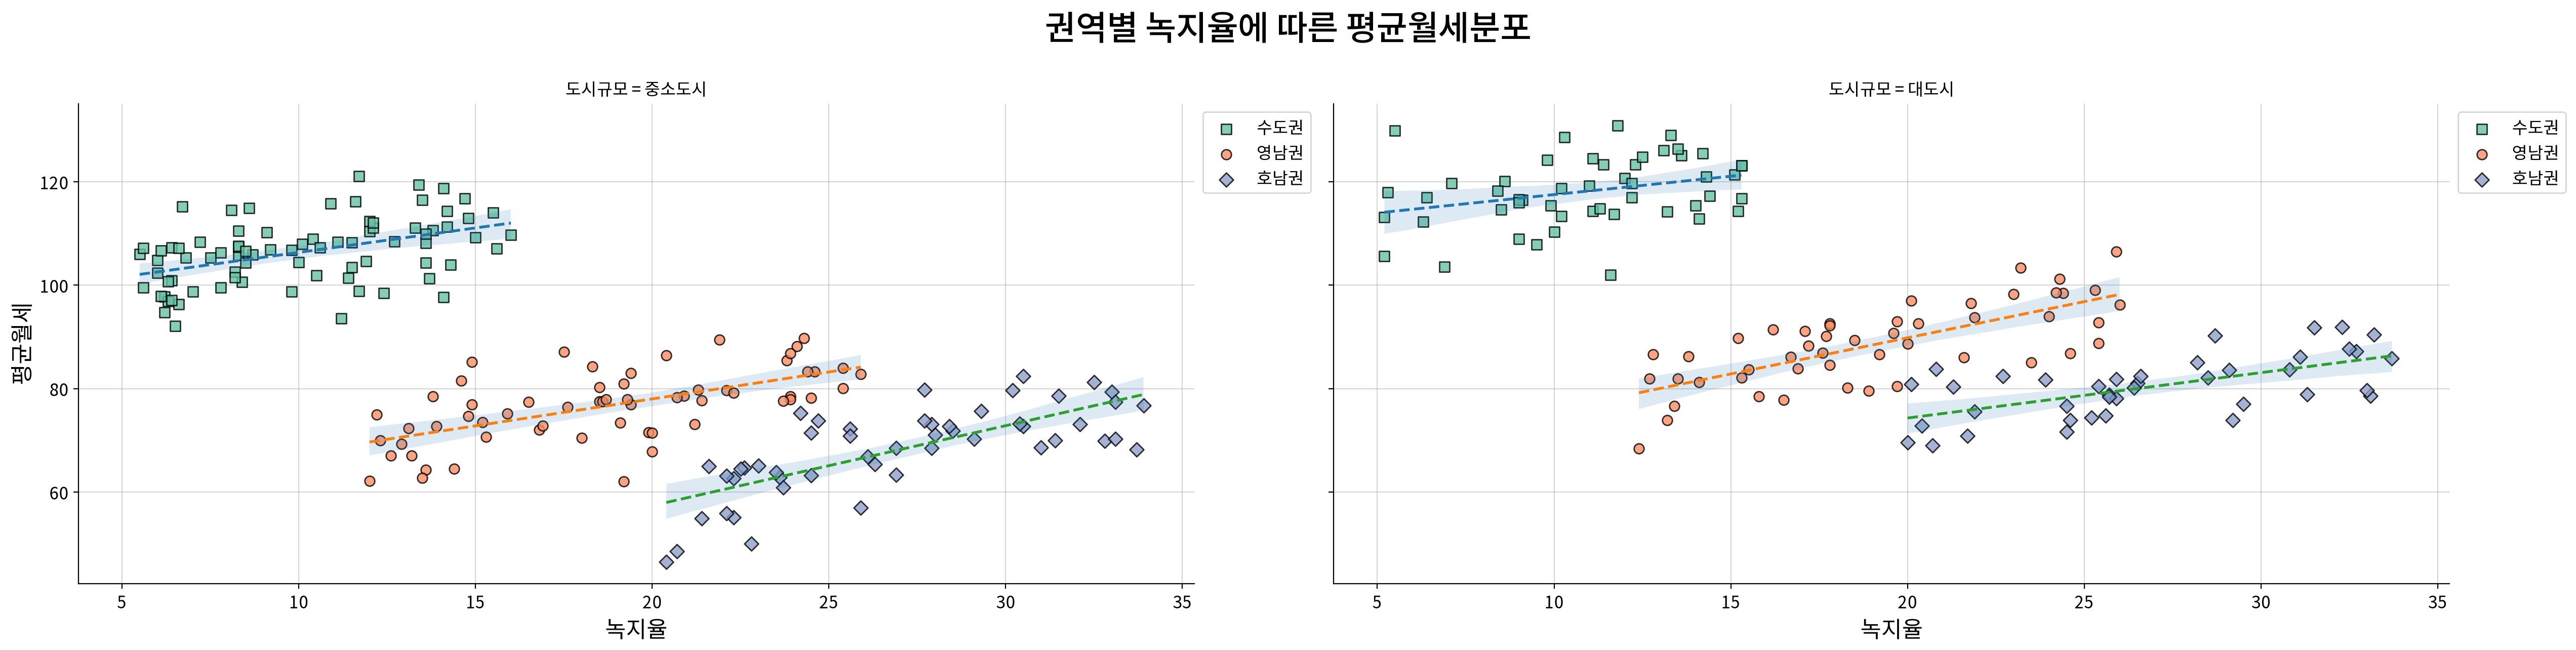

In [17]:
# lmplot그리기 (모듈사용)
my_plot.lmplot(data=df, x="녹지율", y="평균월세", hue="권역", col="도시규모",
               title='권역별 녹지율에 따른 평균월세분포', xlabel='녹지율', ylabel='평균월세',
               palette="Set2", markers=["s", "o", "D"], scatter_edgecolor="#000000", scatter_linewidths=1, scatter_size=50,
                 linestyle="--", linewidth=2)

### 문 제 1. 권역별로 녹지율이 높아질수록 평균 월세는 어떻게 되는가?
#### 모든 권역이 녹지율이 증가함에 따라 평균월세가 올라간다. 추세선을 보면 양의 형태로 나온다
### 문 제 2. 도시규모에 따라 권역별로 녹지율과 평균 월세를 시각화 했을 때 어떤 규모의 평균 월세가 더 높다고 볼 수 있는가?
#### 그래프에 보이는 것과 같이 대도시에서 녹지율에 따른 평균월세가 더 높게 형성된다.